In [1]:
# Matrizes de Correlacao para conjunto de dados IJ-044
import altair as alt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Load the dataset
df = pd.read_csv("IJ-044.csv")

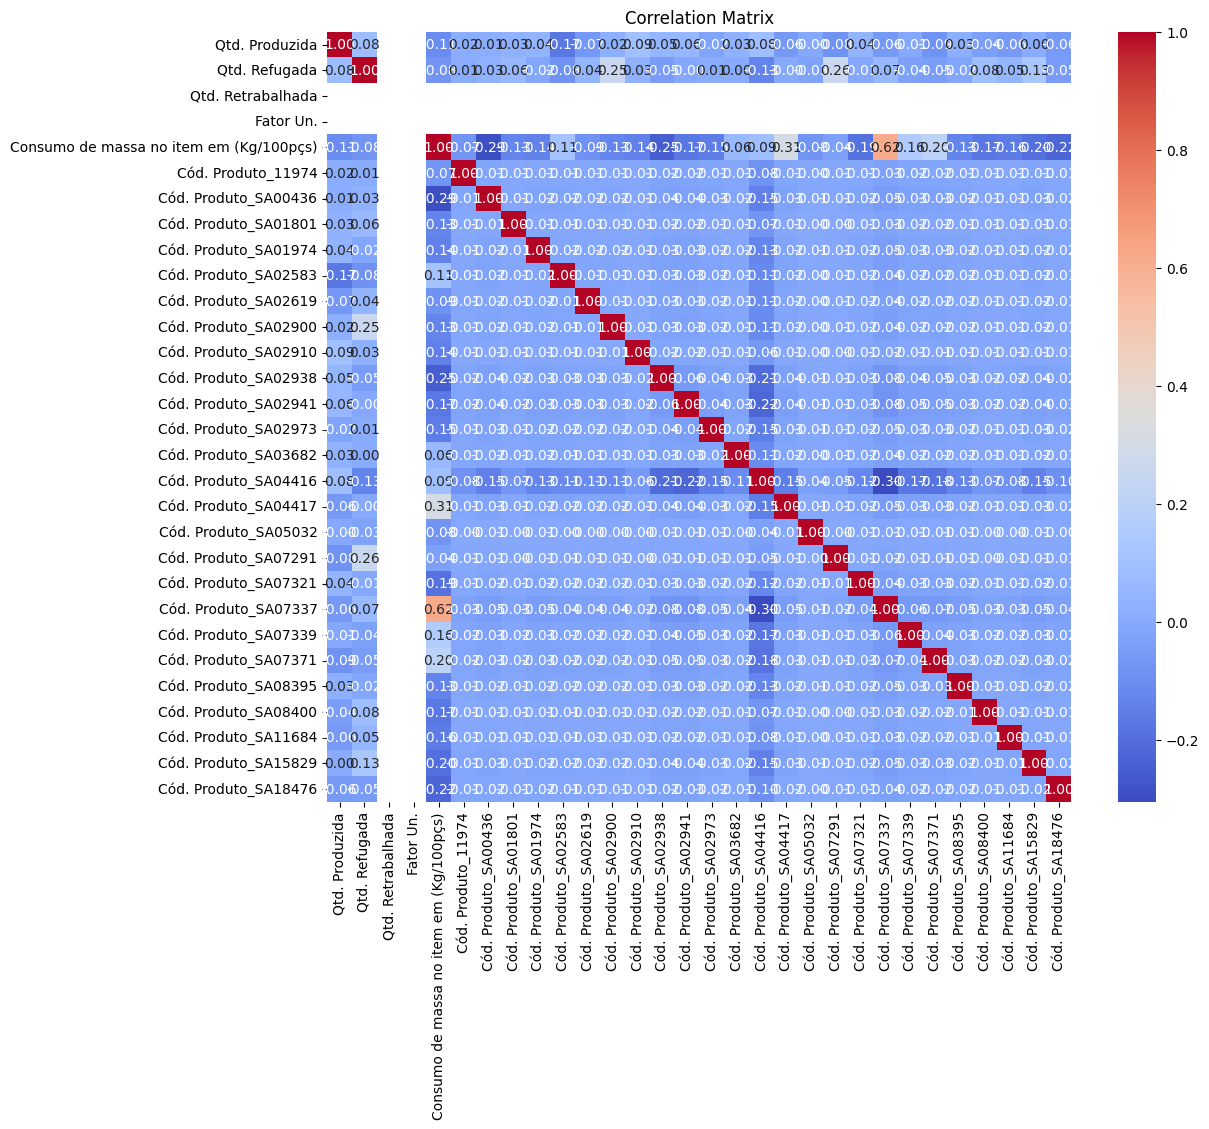

In [2]:
# Convert `Data de Produção` to datetime
df["Data de Produção"] = pd.to_datetime(df["Data de Produção"], format="%Y-%m-%d")

# Drop unnecessary columns
df = df.drop(
    [
        "Data de Produção",
        "Cód. Ordem",
        "Cód. Recurso",
        "Cód. Un.",
        "Descrição da massa (Composto)",
    ],
    axis=1,
)

# One-hot encode `Cód. Produto`
df = pd.get_dummies(df, columns=["Cód. Produto"])

# Calculate the correlation matrix
corr_matrix = df.corr()

# Get the column names
column_names = corr_matrix.columns.tolist()

# Plotting the correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    xticklabels=column_names,
    yticklabels=column_names,
)
plt.title("Correlation Matrix")
plt.savefig("correlation_matrix.png")
plt.show()

In [6]:
# Display the correlation matrix
print(corr_matrix.to_markdown(numalign="left", stralign="left"))

# Prepare data for Altair heatmap
corr_matrix_melted = corr_matrix.reset_index().melt("index")
corr_matrix_melted = corr_matrix_melted.rename(
    columns={"index": "Variable 1", "variable": "Variable 2", "value": "Correlation"}
)

# Create the Altair heatmap
base = alt.Chart(corr_matrix_melted).encode(
    x="Variable 1",
    y="Variable 2",
    color=alt.Color("Correlation", scale=alt.Scale(range="diverging")),
    tooltip=["Variable 1", "Variable 2", "Correlation"],
)

heatmap = base.mark_rect()
text = heatmap.mark_text().encode(color=alt.value("black"), text="Correlation:Q")
chart = heatmap + text
chart = chart.properties(title="Correlation Matrix")

# Save the chart
chart.save("correlation_matrix.json")
chart.save("correlation_matrix.png")

|                                         | Qtd. Produzida   | Qtd. Refugada   | Qtd. Retrabalhada   | Fator Un.   | Consumo de massa no item em (Kg/100pçs)   | Cód. Produto_11974   | Cód. Produto_SA00436   | Cód. Produto_SA01801   | Cód. Produto_SA01974   | Cód. Produto_SA02583   | Cód. Produto_SA02619   | Cód. Produto_SA02900   | Cód. Produto_SA02910   | Cód. Produto_SA02938   | Cód. Produto_SA02941   | Cód. Produto_SA02973   | Cód. Produto_SA03682   | Cód. Produto_SA04416   | Cód. Produto_SA04417   | Cód. Produto_SA05032   | Cód. Produto_SA07291   | Cód. Produto_SA07321   | Cód. Produto_SA07337   | Cód. Produto_SA07339   | Cód. Produto_SA07371   | Cód. Produto_SA08395   | Cód. Produto_SA08400   | Cód. Produto_SA11684   | Cód. Produto_SA15829   | Cód. Produto_SA18476   |
|:----------------------------------------|:-----------------|:----------------|:--------------------|:------------|:------------------------------------------|:---------------------|:-----------------------|:-------

## Análise da Matriz de Correlação

As matrizes de correlação foram geradas e salvas como imagens e arquivos `.json`. A saída também inclui a matriz de correlação em formato de tabela.

### Observações sobre a Matriz de Correlação:

* A diagonal principal da matriz de correlação sempre é 1, pois mostra a correlação de cada variável consigo mesma.
* A matriz é simétrica em relação à diagonal principal, pois a correlação entre as variáveis X e Y é a mesma que entre Y e X.
* As variáveis com correlação próxima de 1 são consideradas altamente correlacionadas positivamente, enquanto as variáveis com correlação próxima de -1 são consideradas altamente correlacionadas negativamente. As variáveis com correlação próxima de 0 não são consideradas muito correlacionadas.
* Neste conjunto de dados específico, parece haver uma correlação positiva entre `Cód. Produto_SA08400` e `Qtd. Refugada`.
* Também pode ser observada uma correlação negativa entre `Cód. Produto_SA02900` e `Cód. Produto_SA07337`.
* `Qtd. Retrabalhada`, `Fator Un.` e algumas outras variáveis têm valores nulos, o que resulta em valores nulos para correlações.
